# Cats vs Dogs — KNN vs K-means, and the M metric

**Question:** if we split the images into two groups **two different ways** — once with
**K-means** (unsupervised, k=2 clusters) and once with **KNN** (supervised, 2 labelled groups) —
do the two splits agree? And *how much* do they disagree?

We measure that disagreement with **M**:

$$M = \frac{1}{N}\sum_{i=1}^{N}\big(\text{label}^{\,\text{KMeans}}_i - \text{label}^{\,\text{KNN}}_i\big)^2$$

Labels are 0/1, so each squared term is **1 when the two methods disagree on an image, 0 when they agree**.
The raw sum is therefore the *number of images they disagree on*; dividing by **N** normalises it to **[0, 1]**:

- **M = 0** → the two partitions are **identical** (perfect match).
- **M = 1** → they disagree on **every** image.
- **M = 0.20** → they disagree on 20% of images; **agreement = 1 − M = 0.80**.

**Label-flip note:** K-means cluster IDs are arbitrary (its "cluster 0" might be the dogs), so before
counting we align K-means to KNN by trying both mappings (as-is and flipped) and keeping the better one.

> This notebook reads the images from your local `microsoft-catsvsdogs-dataset/PetImages` folder,
> exactly like your original notebook. No logistic regression here — only K-means, KNN, and M.


## 0. Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             confusion_matrix, ConfusionMatrixDisplay)

print('Libraries imported.')

Libraries imported.


## 1. Config

Everything you might want to tweak lives here.
`N_PER_CLASS` drives both speed and quality — drop it to 500 for a faster first run.

In [2]:
IMG_SIZE      = 64      # each image -> 64x64 grayscale
N_PER_CLASS   = 1000    # cats + dogs used (1000 + 1000 = 2000 rows)
K_NEIGHBORS   = 5       # k for KNN
RANDOM_STATE  = 42      # reproducibility
CV_FOLDS      = 5       # folds for honest KNN predictions

print(f'IMG_SIZE={IMG_SIZE} | N_PER_CLASS={N_PER_CLASS} | k={K_NEIGHBORS}')

IMG_SIZE=64 | N_PER_CLASS=1000 | k=5


## 2. Load & preprocess the images

Same pipeline as your original notebook: grayscale → resize 64×64 → flatten to 4096 → normalize to 0–1.
Cats = **0**, dogs = **1**. The result is a table `X` (rows = images, columns = pixels) and labels `y`.

In [3]:
DATA_DIR = Path('microsoft-catsvsdogs-dataset') / 'PetImages'
CAT_DIR, DOG_DIR = DATA_DIR / 'Cat', DATA_DIR / 'Dog'
assert CAT_DIR.exists(), f'Cat folder not found at: {CAT_DIR.resolve()}'
assert DOG_DIR.exists(), f'Dog folder not found at: {DOG_DIR.resolve()}'

def list_images(folder):
    return sorted(p for p in folder.iterdir() if p.suffix.lower() == '.jpg')

def load_and_preprocess(files, label, n):
    X, y = [], []
    for path in files[:n]:
        try:
            img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))
            arr = np.asarray(img, dtype=np.float32).flatten() / 255.0
            X.append(arr); y.append(label)
        except Exception:
            continue   # skip corrupt JPEGs
    return X, y

cat_files, dog_files = list_images(CAT_DIR), list_images(DOG_DIR)
cat_X, cat_y = load_and_preprocess(cat_files, 0, N_PER_CLASS)   # cat = 0
dog_X, dog_y = load_and_preprocess(dog_files, 1, N_PER_CLASS)   # dog = 1

X = np.array(cat_X + dog_X)
y = np.array(cat_y + dog_y)
N = len(y)
print('X shape:', X.shape, '| y shape:', y.shape, '| range', X.min(), '-', X.max())
print('cats:', (y==0).sum(), '| dogs:', (y==1).sum())

X shape: (2000, 4096) | y shape: (2000,) | range 0.0 - 1.0
cats: 1000 | dogs: 1000


## 3. Scale features (and a 2-D PCA view for plotting only)

K-means and KNN are both **distance-based**, so we standardise the pixels first (`StandardScaler`) —
otherwise a few bright pixels dominate every distance. We also compute a **2-D PCA** projection: this is
*only* used to draw the 4096-D data on a flat scatter plot, not for the modelling itself.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)
print('Scaled matrix:', X_scaled.shape, '| 2-D projection:', X_2d.shape)
print('Variance explained by the 2 PCA axes:', round(pca2.explained_variance_ratio_.sum()*100, 1), '%')

Scaled matrix: (2000, 4096) | 2-D projection: (2000, 2)
Variance explained by the 2 PCA axes: 32.8 %


## 4. K-means — the *unsupervised* split (k = 2)

K-means never sees `y`. It just groups the 2000 pixel-vectors into two clusters by similarity.

In [5]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X_scaled)
print('K-means cluster sizes:', np.bincount(km_labels))

K-means cluster sizes: [1031  969]


## 5. KNN — the *supervised* split (2 labelled groups)

KNN needs labels, so we can't just predict on the same points it trained on (with k=1 it would simply
memorise them). Instead we use **5-fold `cross_val_predict`**: every image is predicted by *other* images,
giving an honest KNN label for all 2000 points. We also record how well KNN matches the true cat/dog labels.

In [6]:
knn = KNeighborsClassifier(n_neighbors=K_NEIGHBORS)
knn_labels = cross_val_predict(knn, X_scaled, y, cv=CV_FOLDS)
knn_acc_vs_true = (knn_labels == y).mean()
print('KNN group sizes:', np.bincount(knn_labels))
print(f'KNN accuracy vs true labels: {knn_acc_vs_true:.3f}')

KNN group sizes: [ 998 1002]
KNN accuracy vs true labels: 0.537


## 6. Align K-means to KNN (handle the label flip)

K-means "cluster 1" may correspond to KNN "group 0". We try both mappings and keep whichever agrees more.

In [7]:
def align_kmeans_to_knn(reference, clusters):
    disagree_asis  = (clusters != reference).sum()
    disagree_flip  = ((1 - clusters) != reference).sum()
    if disagree_flip < disagree_asis:
        return (1 - clusters), disagree_flip, True
    return clusters, disagree_asis, False

km_aligned, M_raw, flipped = align_kmeans_to_knn(knn_labels, km_labels)
print('Flip needed?', flipped, '| disagreeing images:', M_raw, 'of', N)

Flip needed? False | disagreeing images: 943 of 2000


## 7. The M metric (normalized 0–1)

$$M = \frac{\text{number of images where KMeans} \neq \text{KNN}}{N}\in[0,1]
\qquad \text{Agreement}=1-M$$

In [8]:
M_raw_check = np.sum((km_aligned - knn_labels) ** 2)   # == number of disagreements (0/1 labels)
M = M_raw_check / N
agreement = 1 - M

assert M_raw_check == M_raw
print(f'M (raw disagreements) : {M_raw_check} / {N}')
print(f'M (normalized 0-1)    : {M:.4f}')
print(f'Agreement (1 - M)     : {agreement:.4f}')
print()
if M == 0:
    print('M = 0  ->  K-means clusters are EXACTLY equal to the KNN groups.')
else:
    print(f'M = {M:.3f}  ->  the two splits disagree on {M*100:.1f}% of images.')

M (raw disagreements) : 943 / 2000
M (normalized 0-1)    : 0.4715
Agreement (1 - M)     : 0.5285

M = 0.471  ->  the two splits disagree on 47.1% of images.


## 8. How the two splits map onto each other — contingency table

Rows = K-means cluster (aligned), columns = KNN group. Big numbers on the diagonal ⇒ good agreement.

,KNN grp 0,KNN grp 1
KMeans → grp 0,543,488
KMeans → grp 1,455,514


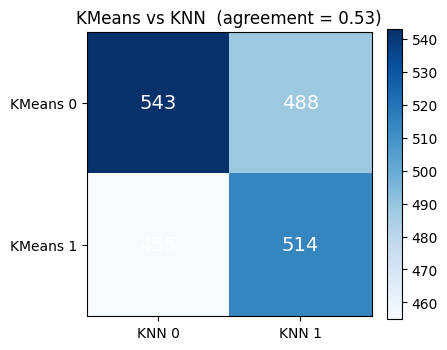

In [9]:
ct = confusion_matrix(km_aligned, knn_labels)
ct_df = pd.DataFrame(ct,
                     index=['KMeans → grp 0', 'KMeans → grp 1'],
                     columns=['KNN grp 0', 'KNN grp 1'])
display(ct_df)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(ct, cmap='Blues')
ax.set_xticks([0, 1], ['KNN 0', 'KNN 1'])
ax.set_yticks([0, 1], ['KMeans 0', 'KMeans 1'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, ct[i, j], ha='center', va='center',
                color='white' if ct[i, j] > ct.max()/2 else 'black', fontsize=14)
ax.set_title(f'KMeans vs KNN  (agreement = {agreement:.2f})')
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 9. The three splits side by side (2-D PCA view)

Same 2000 points three times, coloured by **true label**, by **K-means cluster**, and by **KNN group**.
If K-means matched KNN, the middle and right panels would look identical.

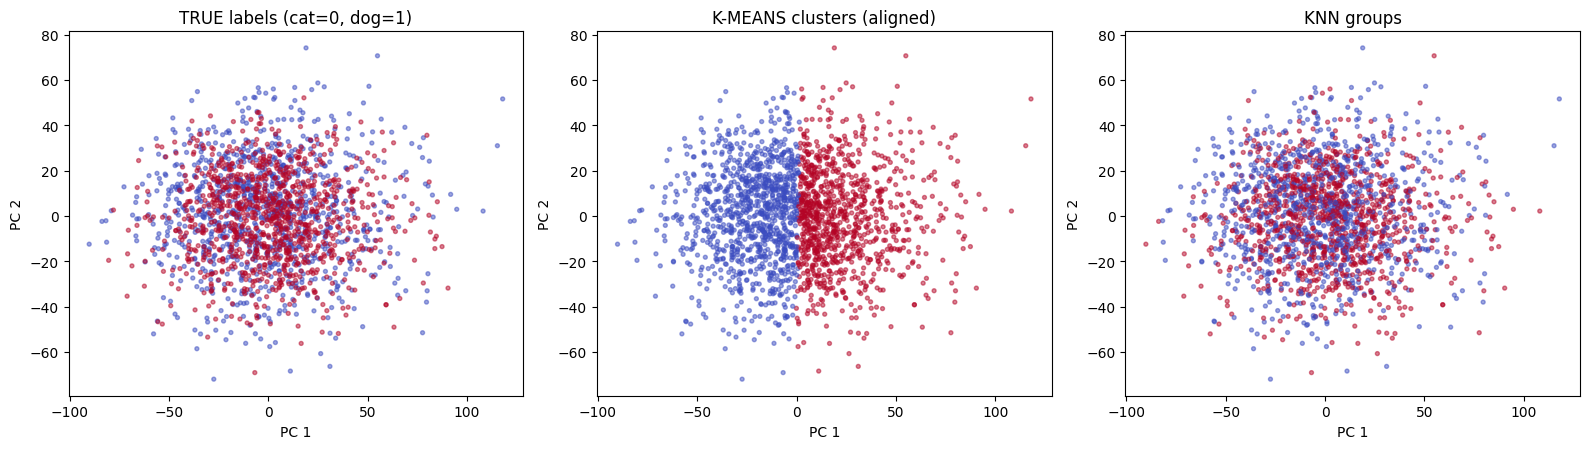

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, lab, title in [(axes[0], y,          'TRUE labels (cat=0, dog=1)'),
                       (axes[1], km_aligned, 'K-MEANS clusters (aligned)'),
                       (axes[2], knn_labels, 'KNN groups')]:
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=lab, cmap='coolwarm', s=8, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

## 10. Where do they agree vs disagree?

Green = both methods put the image in the same group. Red = they disagree (these red points are exactly
the images counted in **M**).

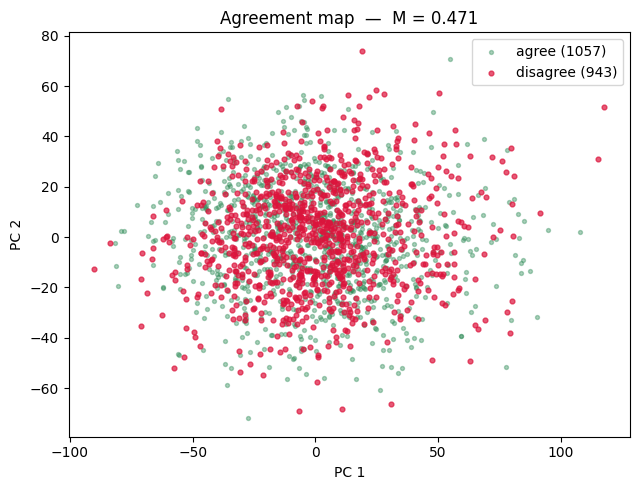

In [11]:
agree_mask = (km_aligned == knn_labels)
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(X_2d[agree_mask, 0],  X_2d[agree_mask, 1],  c='seagreen', s=8,  alpha=0.4, label=f'agree ({agree_mask.sum()})')
ax.scatter(X_2d[~agree_mask, 0], X_2d[~agree_mask, 1], c='crimson',  s=12, alpha=0.7, label=f'disagree ({(~agree_mask).sum()})')
ax.set_title(f'Agreement map  —  M = {M:.3f}'); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(); plt.tight_layout(); plt.show()

## 11. What did K-means actually cluster on?

The images closest to each K-means centroid — the most "typical" members of each cluster. This reveals
*why* the clusters look the way they do (usually overall brightness / background, not cat-vs-dog).

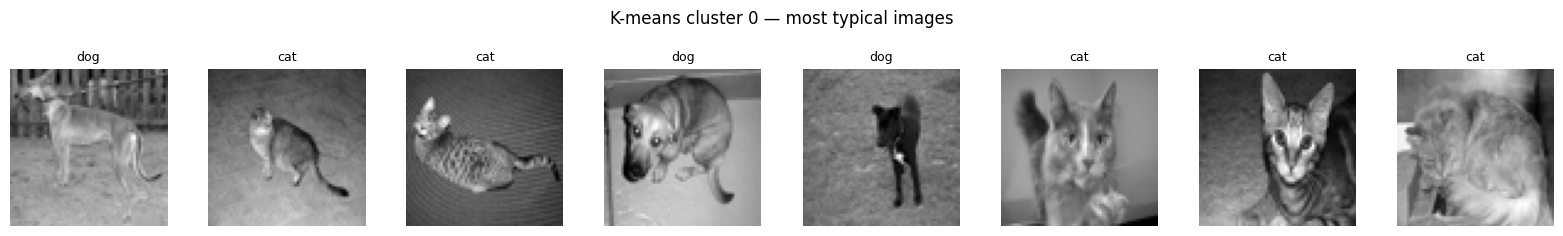

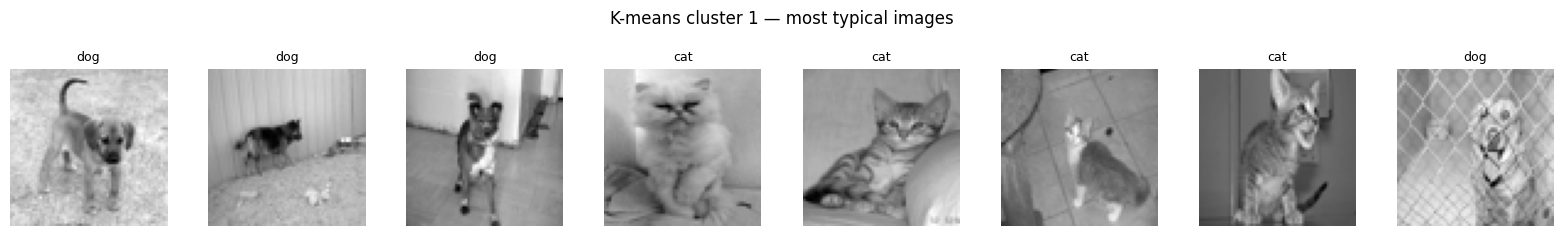

In [12]:
def closest_to_centroid(cluster_id, n=8):
    idx = np.where(km_labels == cluster_id)[0]
    d = np.linalg.norm(X_scaled[idx] - kmeans.cluster_centers_[cluster_id], axis=1)
    return idx[np.argsort(d)[:n]]

for cid in [0, 1]:
    picks = closest_to_centroid(cid, 8)
    fig, axes = plt.subplots(1, 8, figsize=(16, 2.2))
    for ax, i in zip(axes, picks):
        ax.imshow(X[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        ax.set_title('cat' if y[i]==0 else 'dog', fontsize=9); ax.axis('off')
    fig.suptitle(f'K-means cluster {cid} — most typical images', y=1.05)
    plt.tight_layout(); plt.show()

## 12. M at a glance + full metrics table

Alongside **M** we report two standard clustering-agreement scores as a cross-check:
**ARI** (Adjusted Rand Index) and **NMI** (Normalized Mutual Information). Both are flip-proof by
construction, so they should tell the same story as M. We also report each method's accuracy against the
true cat/dog labels.

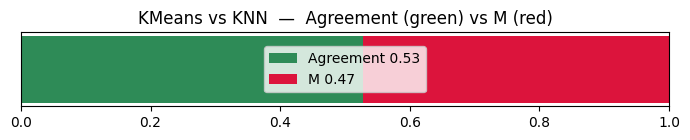

,metric,value
0,M (raw disagreements),943 / 2000
1,M (normalized 0-1),0.4715
2,Agreement (1 - M),0.5285
3,ARI (KMeans vs KNN),0.0028
4,NMI (KMeans vs KNN),0.0024
5,KNN accuracy vs true,0.5370
6,K-means accuracy vs true,0.5175
7,label flip applied?,False


In [13]:
ari = adjusted_rand_score(knn_labels, km_aligned)
nmi = normalized_mutual_info_score(knn_labels, km_aligned)
km_acc_vs_true = max((km_labels == y).mean(), ((1 - km_labels) == y).mean())

# M bar
fig, ax = plt.subplots(figsize=(7, 1.5))
ax.barh([0], [agreement], color='seagreen', label=f'Agreement {agreement:.2f}')
ax.barh([0], [M], left=[agreement], color='crimson', label=f'M {M:.2f}')
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_title('KMeans vs KNN  —  Agreement (green) vs M (red)')
ax.legend(loc='center'); plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'metric': ['M  (raw disagreements)', 'M  (normalized 0-1)', 'Agreement  (1 - M)',
               'ARI (KMeans vs KNN)', 'NMI (KMeans vs KNN)',
               'KNN accuracy vs true', 'K-means accuracy vs true', 'label flip applied?'],
    'value':  [f'{M_raw} / {N}', f'{M:.4f}', f'{agreement:.4f}',
               f'{ari:.4f}', f'{nmi:.4f}',
               f'{knn_acc_vs_true:.4f}', f'{km_acc_vs_true:.4f}', str(flipped)]
})
display(summary)

## 13. Reading the result

- **M is your inaccuracy score**: 0 = the K-means clusters are identical to the KNN groups; the larger M is,
  the more the unsupervised clusters disagree with the supervised groups.
- Because KNN closely tracks the **true** cat/dog labels (see its accuracy above), M is effectively measuring
  **how well K-means recovers the true classes on its own**.
- On raw 64×64 grayscale pixels, expect a **sizeable M** (often ~0.3–0.5). That's the real lesson: K-means
  groups images by brightness and layout, not by "cat vs dog", so unsupervised pixel similarity ≠ semantic class.
  The sample-image panels above usually make this obvious.

**Optional next experiment (section 14):** rerun everything on a compressed **PCA feature space** and watch
whether M drops — a direct demonstration that the *representation*, not the algorithm, is what limits agreement.

## 14. (Optional) Does a better representation lower M?

Rerun K-means + KNN on **PCA-50** features instead of raw pixels, then recompute M. Skip if you just need
the core result above.

In [14]:
X_pca50 = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_scaled)

km2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_pca50)
knn2 = cross_val_predict(KNeighborsClassifier(n_neighbors=K_NEIGHBORS), X_pca50, y, cv=CV_FOLDS)
km2_aligned, M2_raw, flip2 = align_kmeans_to_knn(knn2, km2)
M2 = M2_raw / N

print(f'Raw pixels  ->  M = {M:.4f}  (agreement {1-M:.3f})')
print(f'PCA-50      ->  M = {M2:.4f}  (agreement {1-M2:.3f})')
print('flip on PCA-50 run:', flip2)

Raw pixels  ->  M = 0.4715  (agreement 0.528)
PCA-50      ->  M = 0.4635  (agreement 0.536)
flip on PCA-50 run: True


## 15. M at a glance — how the two splits map onto each other

The number **M** on top, and below it the actual mapping: two **K-means** circles on the left,
two **KNN** circles on the right, sized by how many images each group holds. Every band is a flow
of images from a K-means group into a KNN group.

- **Green bands** (straight across) = both methods put those images in the same group → they agree.
- **Red bands** (crossing over) = the methods split those images differently → these are exactly
  the images counted in **M**.

So M is just the red share of the total width.

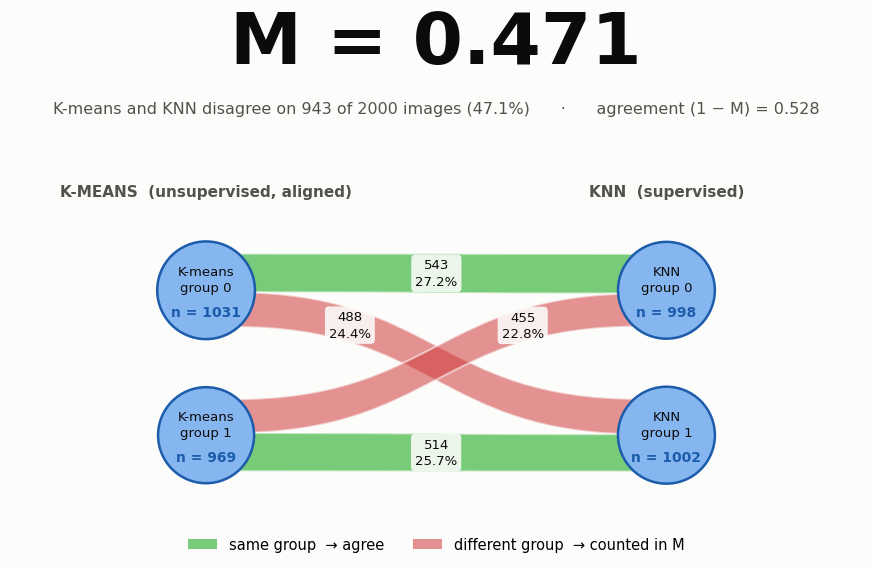

In [15]:
from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch, Circle, Patch

SURFACE, INK, INK_2 = '#fcfcfb', '#0b0b0b', '#52514e'
NODE_FILL, NODE_RING = '#86b6ef', '#1c5cab'
AGREE, DISAGREE      = '#0ca30c', '#d03b3b'

ct = confusion_matrix(km_aligned, knn_labels)      # rows = K-means (aligned), cols = KNN
km_sizes, knn_sizes = ct.sum(axis=1), ct.sum(axis=0)

fig = plt.figure(figsize=(11, 7.2), facecolor=SURFACE)
gs  = fig.add_gridspec(2, 1, height_ratios=[1, 3.2], hspace=0.02)

# ---- hero figure: M -------------------------------------------------------
axh = fig.add_subplot(gs[0]); axh.set_facecolor(SURFACE); axh.axis('off')
axh.text(0.5, 0.80, f'M = {M:.3f}', ha='center', va='center',
         fontsize=52, fontweight='bold', color=INK)
axh.text(0.5, 0.30, f'K-means and KNN disagree on {ct[0, 1] + ct[1, 0]} of {N} images '
                    f'({M*100:.1f}%)      ·      agreement (1 − M) = {agreement:.3f}',
         ha='center', va='center', fontsize=11.5, color=INK_2)

# ---- bipartite mapping: 2 K-means circles <-> 2 KNN circles ---------------
ax = fig.add_subplot(gs[1]); ax.set_facecolor(SURFACE)
ax.set_xlim(0, 10); ax.set_ylim(0, 4.4); ax.set_aspect('equal'); ax.axis('off')

x_km, x_knn = 2.3, 7.7
ys = [3.05, 1.35]                                   # group 0 on top, group 1 below
r_of = lambda n: 0.25 + 0.45 * np.sqrt(n / N)       # area-ish scaling
km_r  = [r_of(km_sizes[i])  for i in (0, 1)]
knn_r = [r_of(knn_sizes[j]) for j in (0, 1)]

def ribbon(xa, ya0, ya1, xb, yb0, yb1, color):
    """Bezier band from the left node's edge to the right node's edge."""
    cx = (xa + xb) / 2
    verts = [(xa, ya0), (cx, ya0), (cx, yb0), (xb, yb0), (xb, yb1),
             (cx, yb1), (cx, ya1), (xa, ya1), (xa, ya0)]
    codes = [MPath.MOVETO, MPath.CURVE4, MPath.CURVE4, MPath.CURVE4, MPath.LINETO,
             MPath.CURVE4, MPath.CURVE4, MPath.CURVE4, MPath.CLOSEPOLY]
    ax.add_patch(PathPatch(MPath(verts, codes), facecolor=color, edgecolor=SURFACE,
                           lw=1.5, alpha=0.55, zorder=1))

def centerline(t, xa, ya, xb, yb):
    """Point at parameter t along the ribbon's centre Bezier — used to place labels."""
    cx = (xa + xb) / 2
    u = 1 - t
    return (u**3 * xa + 3*u**2*t * cx + 3*u*t**2 * cx + t**3 * xb,
            u**3 * ya + 3*u**2*t * ya + 3*u*t**2 * yb + t**3 * yb)

# stack the flows top-to-bottom on each node, Sankey-style
lcur = {i: ys[i] + 0.75 * km_r[i]  for i in (0, 1)}
rcur = {j: ys[j] + 0.75 * knn_r[j] for j in (0, 1)}

for i in (0, 1):
    for j in (0, 1):
        c = ct[i, j]
        ya0, ya1 = lcur[i], lcur[i] - 1.5 * km_r[i]  * c / km_sizes[i]
        yb0, yb1 = rcur[j], rcur[j] - 1.5 * knn_r[j] * c / knn_sizes[j]
        lcur[i], rcur[j] = ya1, yb1
        xa, xb = x_km + 0.55 * km_r[i], x_knn - 0.55 * knn_r[j]
        ribbon(xa, ya0, ya1, xb, yb0, yb1, AGREE if i == j else DISAGREE)
        # the two disagree ribbons cross at the centre, so park their labels
        # off-centre (one early, one late) instead of on top of each other
        t = 0.5 if i == j else (0.24 if i < j else 0.76)
        lx, ly = centerline(t, xa, (ya0 + ya1) / 2, xb, (yb0 + yb1) / 2)
        ax.text(lx, ly, f'{c}\n{c/N*100:.1f}%', ha='center', va='center',
                fontsize=9.5, color=INK, linespacing=1.35, zorder=4,
                bbox=dict(boxstyle='round,pad=0.30', fc=SURFACE, ec='none', alpha=0.88))

for x, radii, sizes, name in [(x_km, km_r, km_sizes, 'K-means'),
                              (x_knn, knn_r, knn_sizes, 'KNN')]:
    for g in (0, 1):
        ax.add_patch(Circle((x, ys[g]), radii[g], facecolor=NODE_FILL,
                            edgecolor=NODE_RING, lw=1.8, zorder=3))
        ax.text(x, ys[g] + 0.13, f'{name}\ngroup {g}', ha='center', va='center',
                fontsize=9.5, color=INK, linespacing=1.3, zorder=4)
        ax.text(x, ys[g] - 0.26, f'n = {sizes[g]}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=NODE_RING, zorder=4)

ax.text(x_km,  4.15, 'K-MEANS  (unsupervised, aligned)', ha='center', fontsize=11,
        fontweight='bold', color=INK_2)
ax.text(x_knn, 4.15, 'KNN  (supervised)', ha='center', fontsize=11,
        fontweight='bold', color=INK_2)
ax.legend(handles=[Patch(facecolor=AGREE, alpha=0.55, label='same group  → agree'),
                   Patch(facecolor=DISAGREE, alpha=0.55, label='different group  → counted in M')],
          loc='lower center', bbox_to_anchor=(0.5, -0.04), ncol=2,
          frameon=False, fontsize=10.5)

plt.show()